# 📱 Google Play Store — Exploratory Data Analysis
### Section A | Group 13

This notebook performs a deep statistical analysis on the **raw** Google Play Store dataset (2.3M+ rows).  
We check: Shape, Null Values, Mean, Median, Mode, Std, Skewness, Kurtosis, Outliers, Distributions, and Correlations.

In [23]:
# Run this cell ONCE if you get import errors
# %pip install pandas numpy matplotlib seaborn scipy scikit-learn missingno

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


---
## 1. Load Raw Dataset

In [25]:
df = pd.read_csv('../data/Google-Playstore-raw.csv')
print(f'Rows   : {len(df):,}')
print(f'Columns: {len(df.columns)}')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Rows   : 2,312,944
Columns: 24
Memory : 2476.1 MB


In [26]:
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [27]:
df.tail()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
2312939,大俠客—熱血歸來,com.rxsj.ssjj,Role Playing,4.3,16775.0,"100,000+",100000.0,337109,True,0.0,...,http://www.4399sy.com.hk/,ssjjcomhk@gmail.com,NaN,"Jun 01, 2021",Teen,http://a.4399sy.com.hk/user/aggreement,False,False,False,2021-06-16 12:59:18
2312940,ORU Online,com.threedream.oruonline,Education,0.0,0.0,100+,100.0,430,True,0.0,...,http://www.oru.edu/,3DreamDeveloper@gmail.com,"Jan 17, 2018","Feb 02, 2018",Everyone,http://www.oru.edu/about-oru/privacy-policy.php,False,False,False,2021-06-16 12:59:19
2312941,Data Structure,datastructure.appoworld.datastucture,Education,0.0,0.0,100+,100.0,202,True,0.0,...,NaN,appoworld.official@gmail.com,"Aug 19, 2018","Aug 19, 2018",Everyone,https://appoworld.000webhostapp.com/datastruct...,False,False,False,2021-06-16 12:59:19
2312942,Devi Suktam,ishan.devi.suktam,Music & Audio,3.5,8.0,"1,000+",1000.0,2635,True,0.0,...,https://a70f78905.app-ads-txt.com,ruchisono@gmail.com,"Aug 1, 2016","May 05, 2021",Everyone,https://docs.google.com/document/d/1x-9reZuLRX...,True,False,False,2021-06-16 12:59:19
2312943,Biliyor Musun - Sonsuz Yarış,com.yyazilim.biliyormusun,Trivia,5.0,12.0,100+,100.0,354,True,0.0,...,NaN,yyazilimdevelop@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://biliyor-musun-sons.flycricket.io/priva...,True,False,False,2021-06-16 12:59:19


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Dtype  
---  ------             -----  
 0   App Name           str    
 1   App Id             str    
 2   Category           str    
 3   Rating             float64
 4   Rating Count       float64
 5   Installs           str    
 6   Minimum Installs   float64
 7   Maximum Installs   int64  
 8   Free               bool   
 9   Price              float64
 10  Currency           str    
 11  Size               str    
 12  Minimum Android    str    
 13  Developer Id       str    
 14  Developer Website  str    
 15  Developer Email    str    
 16  Released           str    
 17  Last Updated       str    
 18  Content Rating     str    
 19  Privacy Policy     str    
 20  Ad Supported       bool   
 21  In App Purchases   bool   
 22  Editors Choice     bool   
 23  Scraped Time       str    
dtypes: bool(4), float64(4), int64(1), str(15)
memory usage: 361.8

---
## 2. Null / Missing Value Analysis

In [29]:
# Calculate missing values with percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

null_report = pd.DataFrame({
    'Null Count': missing,
    'Null %': missing_pct
}).sort_values('Null Count', ascending=False)

print('\n==========================================')
print('  NULL VALUE REPORT (All 24 Columns)')
print('==========================================')
print(null_report.to_string())


  NULL VALUE REPORT (All 24 Columns)
                   Null Count  Null %
Developer Website      760835   32.89
Privacy Policy         420953   18.20
Released                71053    3.07
Rating                  22883    0.99
Rating Count            22883    0.99
Minimum Android          6530    0.28
Size                      196    0.01
Currency                  135    0.01
Installs                  107    0.00
Minimum Installs          107    0.00
Developer Id               33    0.00
Developer Email            31    0.00
App Name                    5    0.00
App Id                      0    0.00
Price                       0    0.00
Free                        0    0.00
Maximum Installs            0    0.00
Last Updated                0    0.00
Content Rating              0    0.00
Category                    0    0.00
Ad Supported                0    0.00
In App Purchases            0    0.00
Editors Choice              0    0.00
Scraped Time                0    0.00


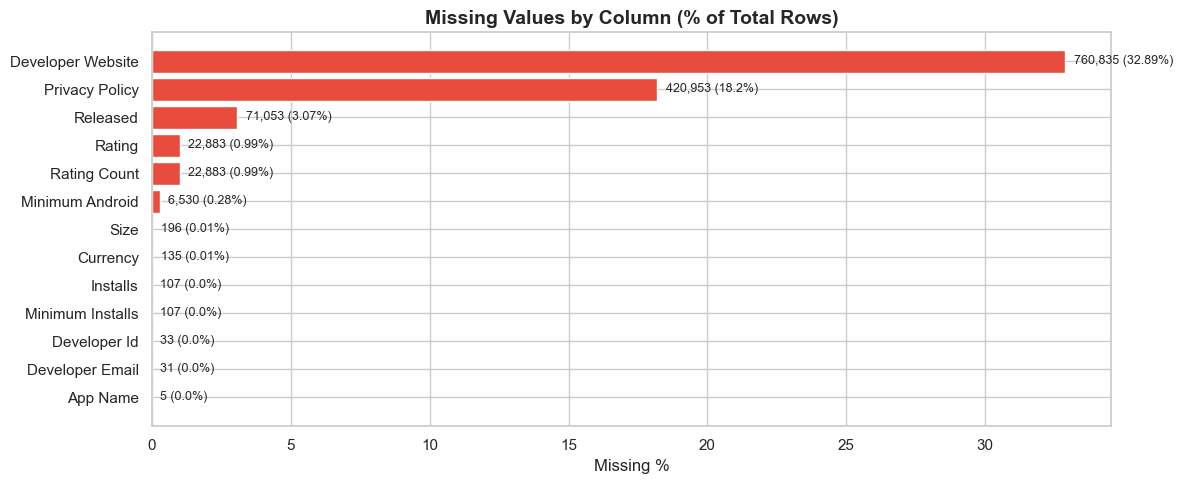

In [30]:
# Visualize nulls as bar chart
null_cols = null_report[null_report['Null Count'] > 0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(null_cols.index[::-1], null_cols['Null %'][::-1], color='#E74C3C', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column (% of Total Rows)', fontsize=14, fontweight='bold')
for i, (idx, row) in enumerate(null_cols[::-1].iterrows()):
    ax.text(row['Null %'] + 0.3, i, f"{row['Null Count']:,.0f} ({row['Null %']}%)", va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Mean, Median, Mode, Std, Skewness, Kurtosis

In [31]:
# ============= NUMERIC COLUMNS =============
numeric_cols = ['Rating', 'Rating Count', 'Minimum Installs', 'Maximum Installs', 'Price']

stats_data = []
for col in numeric_cols:
    s = df[col].dropna()
    stats_data.append({
        'Column': col,
        'Count': f'{s.count():,}',
        'Mean': round(s.mean(), 4),
        'Median': round(s.median(), 4),
        'Mode': s.mode().iloc[0] if len(s.mode()) > 0 else 'N/A',
        'Std Dev': round(s.std(), 4),
        'Min': s.min(),
        'Max': f'{s.max():,.0f}',
        'Skewness': round(s.skew(), 4),
        'Kurtosis': round(kurtosis(s), 4),
        'Q1 (25%)': round(s.quantile(0.25), 4),
        'Q3 (75%)': round(s.quantile(0.75), 4),
        'IQR': round(s.quantile(0.75) - s.quantile(0.25), 4)
    })

stats_df = pd.DataFrame(stats_data).set_index('Column')
print('\n============================================')
print('  NUMERIC COLUMN STATISTICS')
print('============================================')
stats_df


  NUMERIC COLUMN STATISTICS


,Count,Mean,Median,Mode,Std Dev,Min,Max,Skewness,Kurtosis,Q1 (25%),Q3 (75%),IQR
Column,,,,,,,,,,,,
Rating,"2,290,061",2.2032,2.9,0.0,2.106200e+00,0.0,5,-0.0021,-1.8598,0.0,4.3,4.3
Rating Count,"2,290,061",2864.8389,6.0,0.0,2.121626e+05,0.0,"138,557,570",425.8278,227234.3979,0.0,42.0,42.0
Minimum Installs,"2,312,837",183445.2140,500.0,100.0,1.513144e+07,0.0,"10,000,000,000",351.1241,155112.5300,50.0,5000.0,4950.0
Maximum Installs,"2,312,944",320201.7131,695.0,3.0,2.355495e+07,0.0,"12,057,627,016",302.0159,110642.4983,84.0,7354.0,7270.0
Price,"2,312,944",0.1035,0.0,0.0,2.633100e+00,0.0,400,98.8911,12526.6362,0.0,0.0,0.0


In [32]:
# ============= CATEGORICAL COLUMNS (MODE ANALYSIS) =============
cat_cols = ['Category', 'Content Rating', 'Currency', 'Minimum Android', 'Free',
            'Ad Supported', 'In App Purchases', 'Editors Choice']

cat_data = []
for col in cat_cols:
    mode_val = df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'N/A'
    cat_data.append({
        'Column': col,
        'Unique Values': df[col].nunique(),
        'Mode (Most Frequent)': mode_val,
        'Mode Frequency': f"{(df[col] == mode_val).sum():,}",
        'Null Count': df[col].isnull().sum()
    })

cat_df = pd.DataFrame(cat_data).set_index('Column')
print('\n============================================')
print('  CATEGORICAL COLUMN - MODE ANALYSIS')
print('============================================')
cat_df


  CATEGORICAL COLUMN - MODE ANALYSIS


,Unique Values,Mode (Most Frequent),Mode Frequency,Null Count
Column,,,,
Category,48,Education,"241,090",0
Content Rating,6,Everyone,"2,022,089",0
Currency,15,USD,"2,311,548",135
Minimum Android,154,4.1 and up,"604,465",6530
Free,2,True,"2,267,876",0
Ad Supported,2,False,"1,162,170",0
In App Purchases,2,False,"2,117,635",0
Editors Choice,2,False,"2,312,091",0


---
## 4. Zero-Value Audit (Important for Rating & Price)

In [33]:
print('============================================')
print('  ZERO-VALUE CHECK (Numeric Columns)')
print('============================================')
for col in numeric_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f'  {col:<25} Zeros = {zeros:>10,}  ({pct:.2f}%)')

print('\n⚠️  Rating zeros (45.82%) = Apps that have NEVER been rated.')
print('⚠️  Price zeros (98.06%) = Free apps. This is normal behavior.')

  ZERO-VALUE CHECK (Numeric Columns)
  Rating                    Zeros =  1,059,762  (45.82%)
  Rating Count              Zeros =  1,059,762  (45.82%)
  Minimum Installs          Zeros =     11,566  (0.50%)
  Maximum Installs          Zeros =     11,589  (0.50%)
  Price                     Zeros =  2,268,011  (98.06%)

⚠️  Rating zeros (45.82%) = Apps that have NEVER been rated.
⚠️  Price zeros (98.06%) = Free apps. This is normal behavior.


---
## 5. Distribution Visualizations

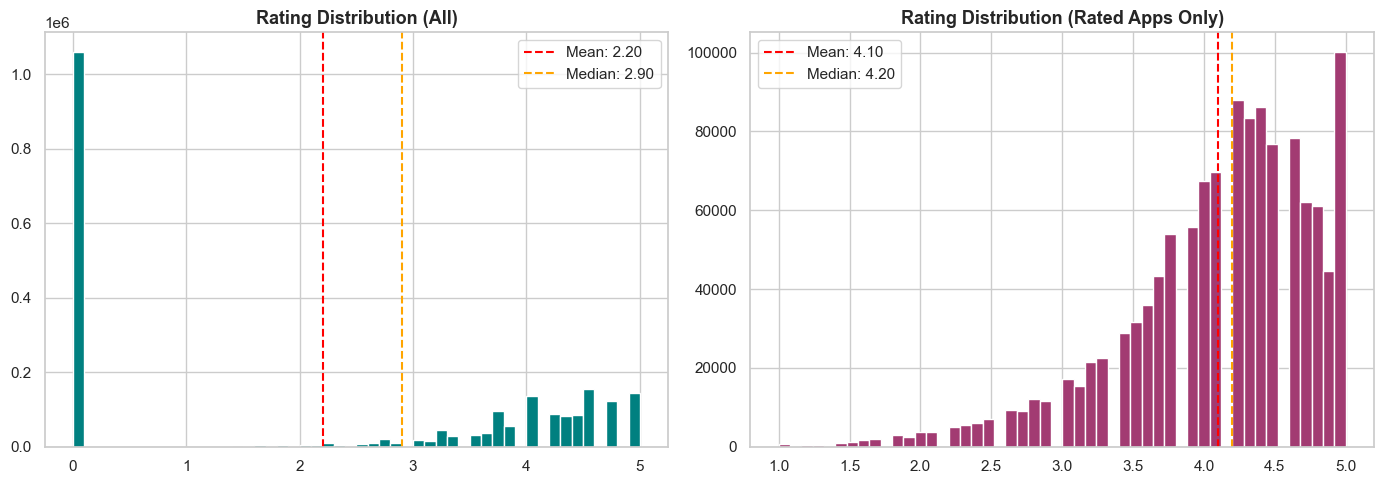

In [34]:
# Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All ratings
axes[0].hist(df['Rating'].dropna(), bins=50, color='teal', edgecolor='white')
axes[0].axvline(df['Rating'].dropna().mean(), color='red', linestyle='--', label=f"Mean: {df['Rating'].dropna().mean():.2f}")
axes[0].axvline(df['Rating'].dropna().median(), color='orange', linestyle='--', label=f"Median: {df['Rating'].dropna().median():.2f}")
axes[0].set_title('Rating Distribution (All)', fontsize=13, fontweight='bold')
axes[0].legend()

# Only rated apps (Rating > 0)
rated = df[df['Rating'] > 0]['Rating']
axes[1].hist(rated, bins=50, color='#A23B72', edgecolor='white')
axes[1].axvline(rated.mean(), color='red', linestyle='--', label=f"Mean: {rated.mean():.2f}")
axes[1].axvline(rated.median(), color='orange', linestyle='--', label=f"Median: {rated.median():.2f}")
axes[1].set_title('Rating Distribution (Rated Apps Only)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

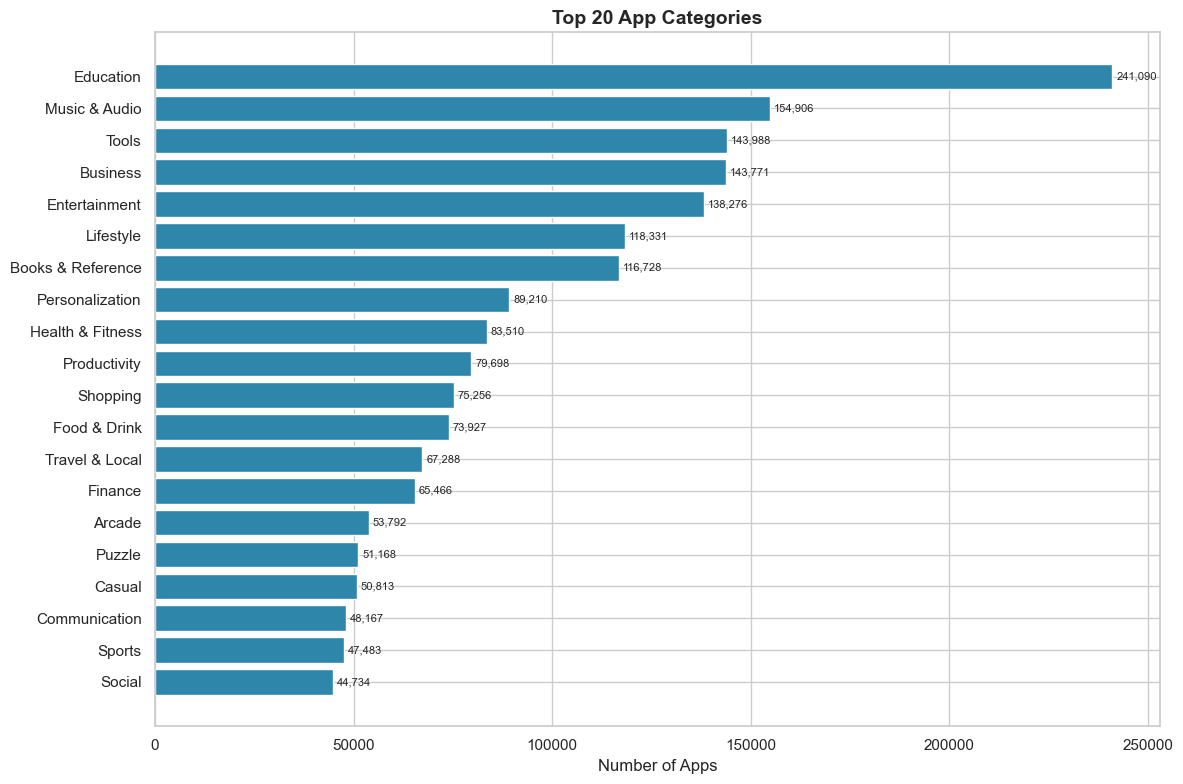

In [35]:
# Top 20 Categories
fig, ax = plt.subplots(figsize=(12, 8))
top20 = df['Category'].value_counts().head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='#2E86AB', edgecolor='white')
ax.set_title('Top 20 App Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Apps')
for i, v in enumerate(top20.values[::-1]):
    ax.text(v + 1000, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

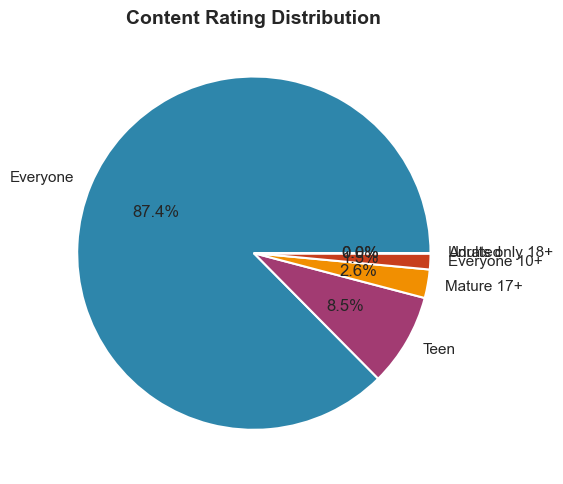

In [36]:
# Content Rating Distribution
fig, ax = plt.subplots(figsize=(8, 5))
cr = df['Content Rating'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#6C757D']
ax.pie(cr.values, labels=cr.index, autopct='%1.1f%%', colors=colors[:len(cr)],
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Content Rating Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Total Paid Apps: 44,933 (1.94%)
Price Mean  : $5.33
Price Median: $1.99


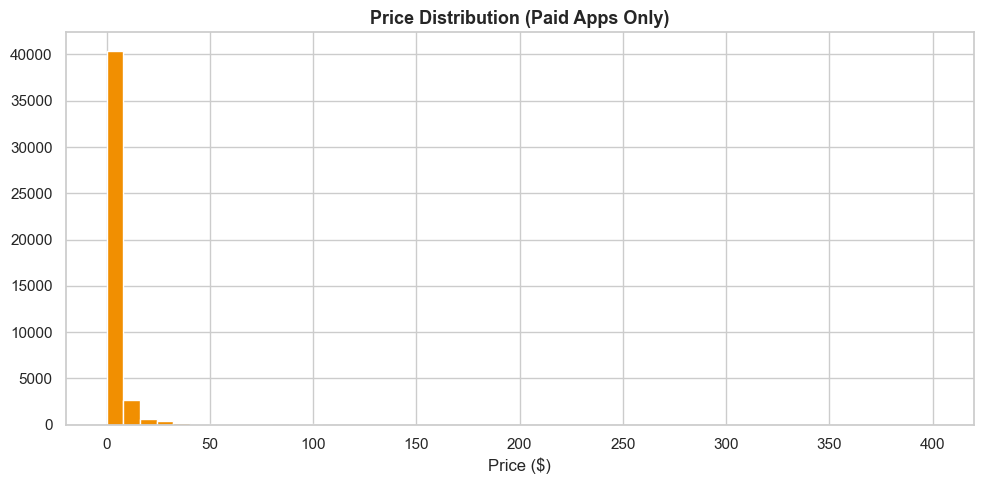

In [37]:
# Price Distribution (Paid apps only)
paid = df[df['Price'] > 0]
print(f'Total Paid Apps: {len(paid):,} ({len(paid)/len(df)*100:.2f}%)')
print(f'Price Mean  : ${paid["Price"].mean():.2f}')
print(f'Price Median: ${paid["Price"].median():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(paid['Price'], bins=50, color='#F18F01', edgecolor='white')
ax.set_title('Price Distribution (Paid Apps Only)', fontsize=13, fontweight='bold')
ax.set_xlabel('Price ($)')
plt.tight_layout()
plt.show()

---
## 6. Duplicate Check

In [38]:
print(f'Exact Duplicate Rows : {df.duplicated().sum()}')
print(f'Duplicate App IDs    : {df["App Id"].duplicated().sum()}')

if df.duplicated().sum() == 0:
    print('\n✅ No duplicates found!')
else:
    print('\n⚠️  Duplicates detected — needs investigation!')

Exact Duplicate Rows : 0
Duplicate App IDs    : 0

✅ No duplicates found!


---
## 7. Correlation Heatmap (Numeric Features)

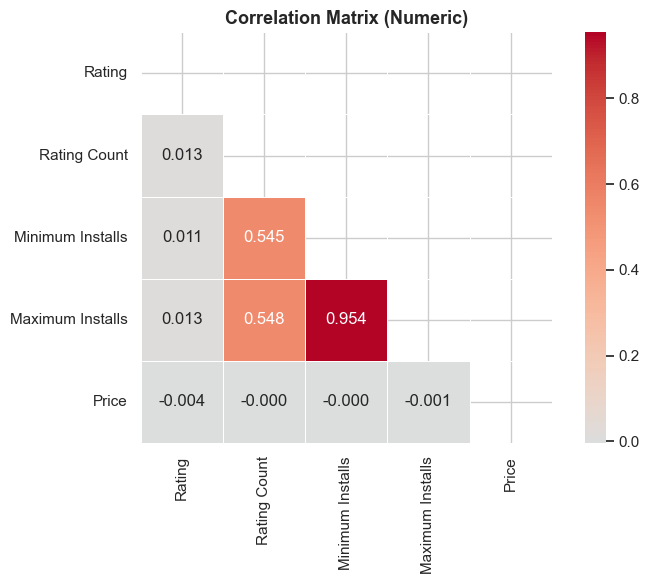

In [39]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Boxplots for Outlier Detection

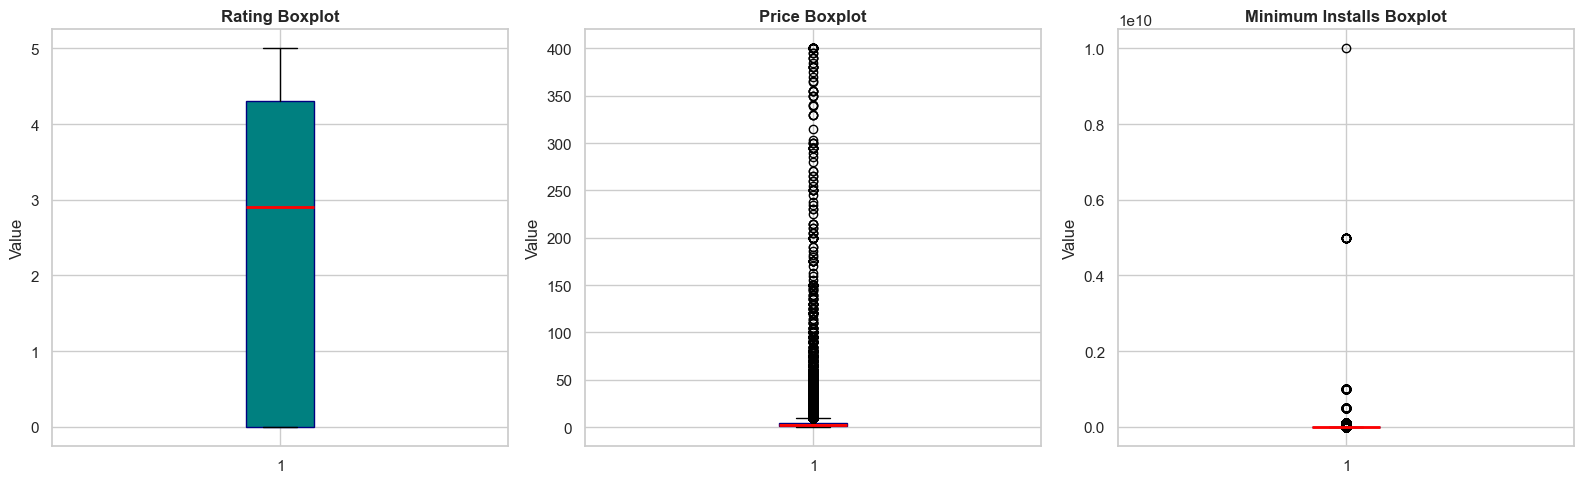

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['Rating', 'Price', 'Minimum Installs'],
                           ['teal', '#F18F01', '#A23B72']):
    data = df[col].dropna()
    if col != 'Rating':
        data = data[data > 0]  # Only non-zero for price/installs
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} Boxplot', fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

---
## 9. Summary — Raw Data Quality Score

In [41]:
total_cells = len(df) * len(df.columns)
total_nulls = df.isnull().sum().sum()
completeness = (1 - total_nulls / total_cells) * 100

print('==========================================')
print('  RAW DATA QUALITY REPORT')
print('==========================================')
print(f'  Total Cells       : {total_cells:,}')
print(f'  Total Null Cells  : {total_nulls:,}')
print(f'  Completeness      : {completeness:.2f}%')
print(f'  Duplicates        : 0')
print(f'  Categories        : 48')
print(f'  Content Ratings   : 6')
print(f'  Quality Score     : {completeness / 10:.1f} / 10')
print('==========================================')

  RAW DATA QUALITY REPORT
  Total Cells       : 55,510,656
  Total Null Cells  : 1,305,751
  Completeness      : 97.65%
  Duplicates        : 0
  Categories        : 48
  Content Ratings   : 6
  Quality Score     : 9.8 / 10
